# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Isi Nama Kalian| Isi NRP Kalian|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')
print(df.shape)
df.info()
print(df.describe())
print('Jumlah missing value per kolom:')
print(df.isnull().sum())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std       3.36

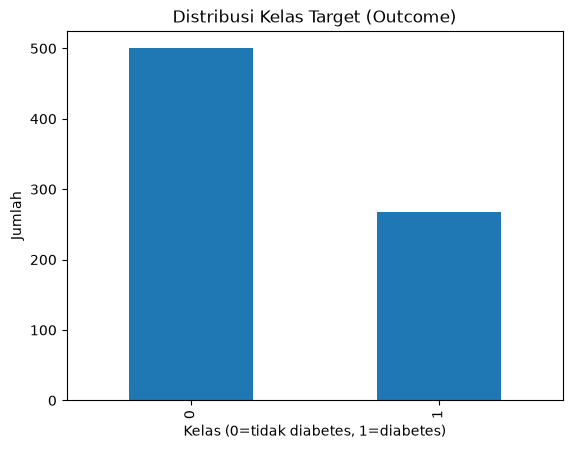

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
df['Outcome'].value_counts().plot(kind='bar', title='Distribusi Kelas Target (Outcome)', xlabel='Kelas (0=tidak diabetes, 1=diabetes)', ylabel='Jumlah')
plt.show()

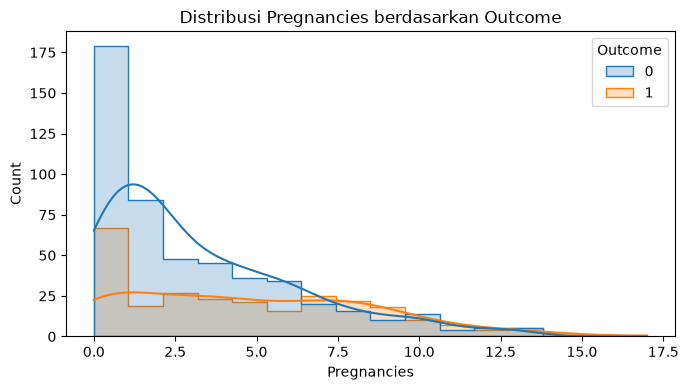

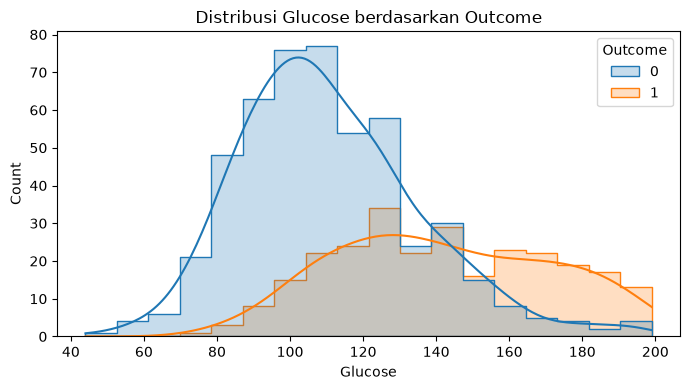

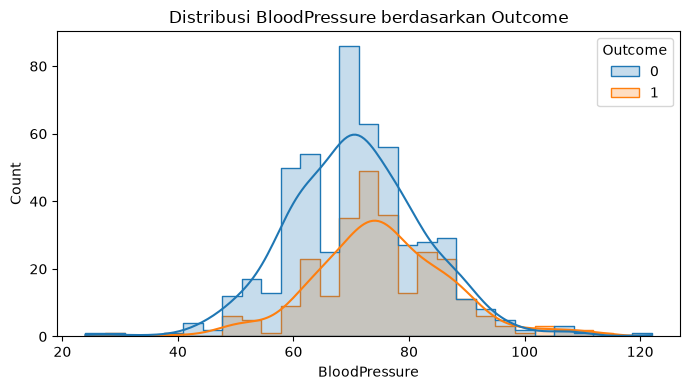

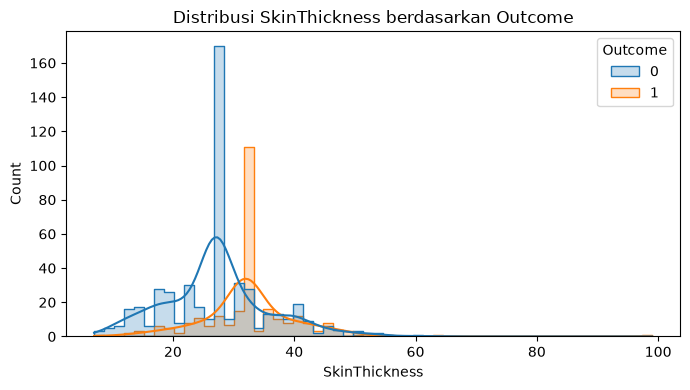

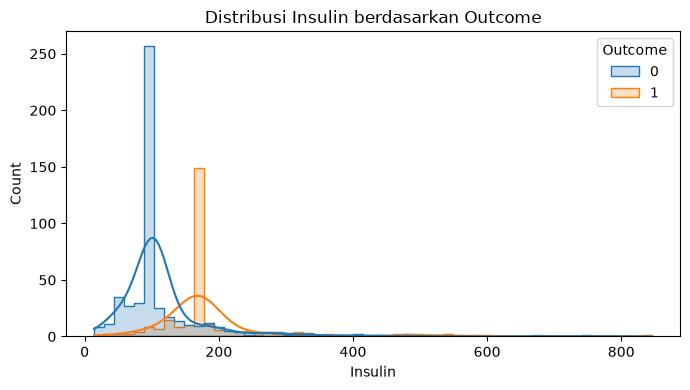

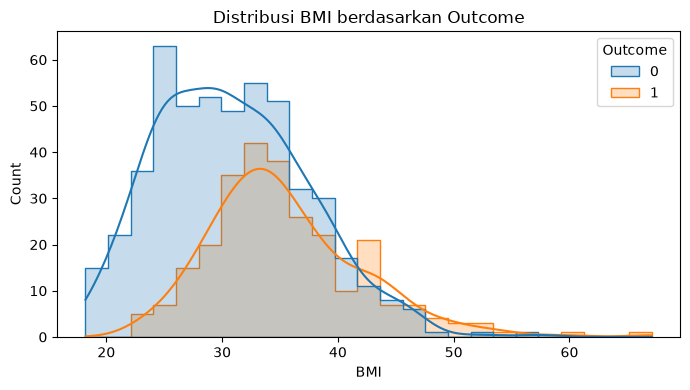

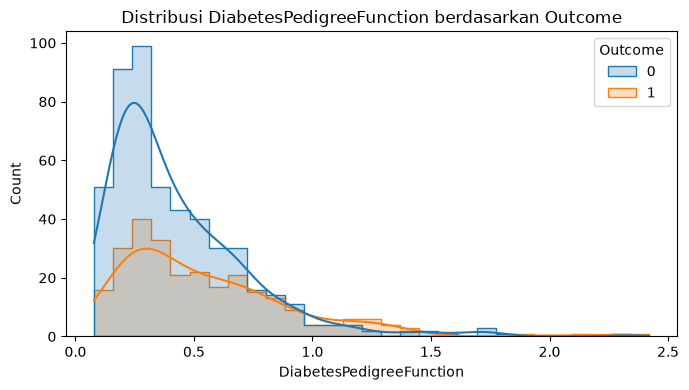

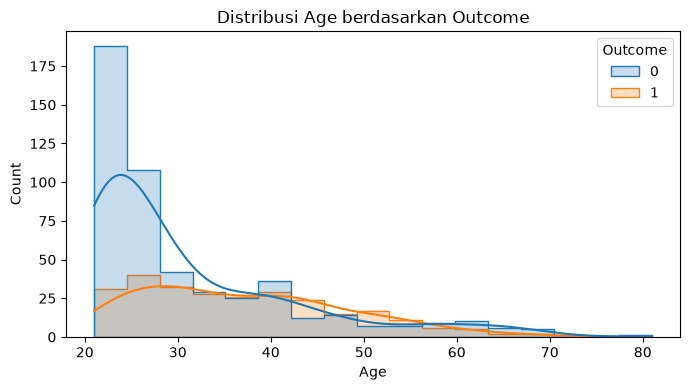

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = df.drop(columns=['Outcome']).columns
for col in features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, element='step')
    plt.title(f'Distribusi {col} berdasarkan Outcome')
    plt.tight_layout()
    plt.show()

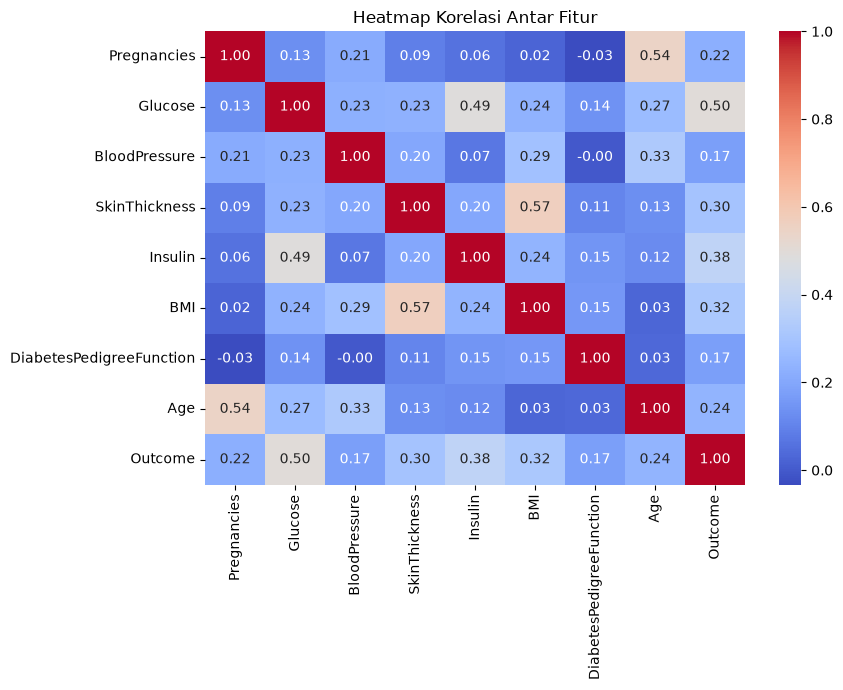

In [5]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Pregnancies                 0.901674
Glucose                     0.532324
BloodPressure               0.140830
SkinThickness               0.817477
Insulin                     3.028046
BMI                         0.606416
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64


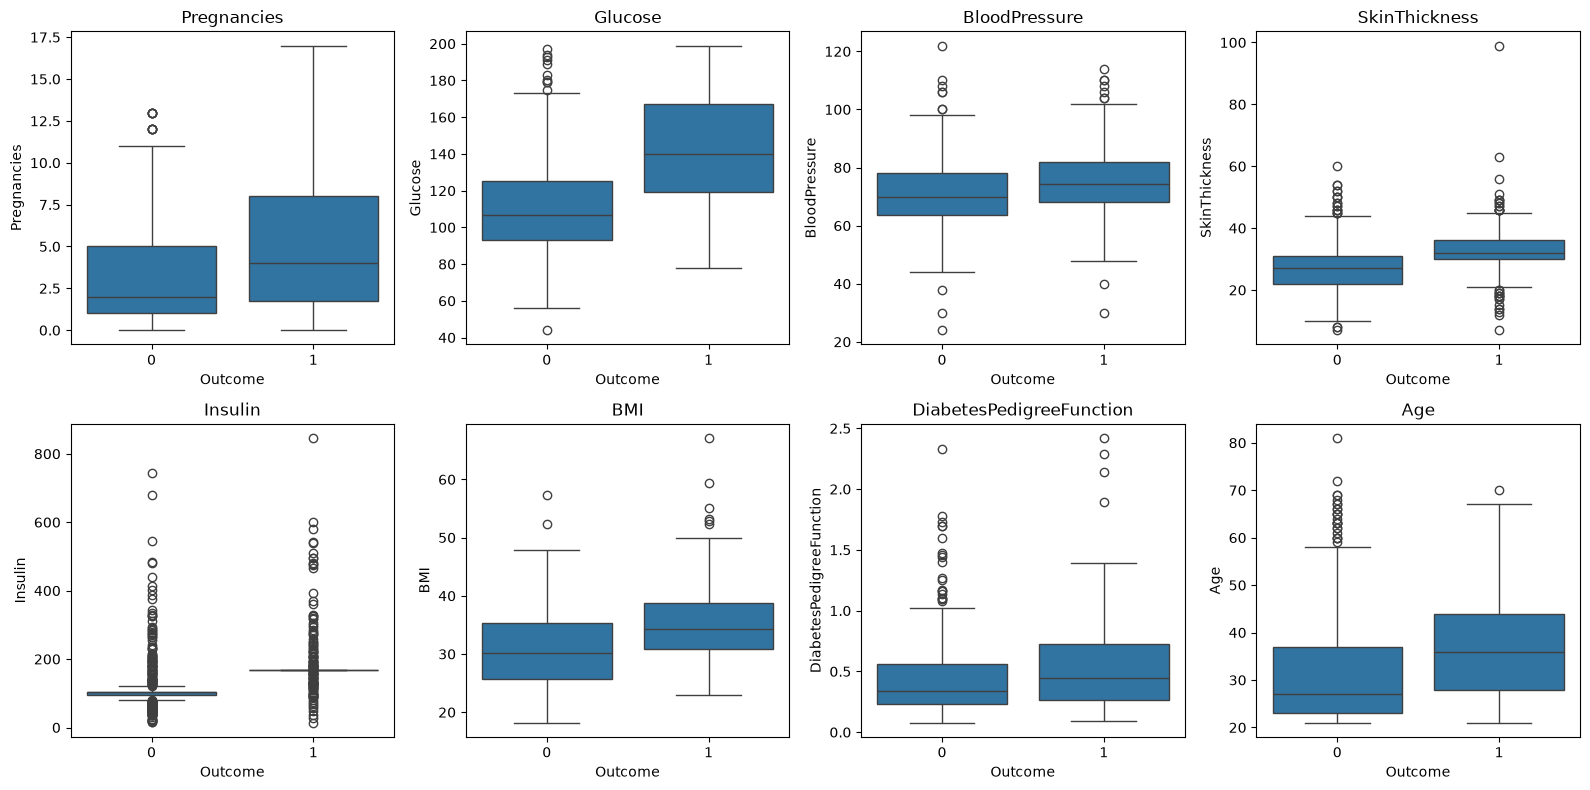

In [6]:
# EDA tambahan: cek outlier tiap fitur per kelas dengan boxplot dan kemiringan distribusi.
print(df.skew(numeric_only=True))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, df.drop(columns=['Outcome']).columns):
    sns.boxplot(data=df, x='Outcome', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[zero_cols] == 0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [8]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Hasil pengecekan: dataset ini sudah bersih (tidak ada nilai 0 maupun NaN pada kolom di atas),
# sehingga kode di bawah hanya pengaman dan tidak mengubah data. Jika ada missing sungguhan,
# median wajib dihitung dari train set saja (setelah split) agar tidak terjadi leakage.
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
print('NaN setelah penandaan 0:', int(df[zero_cols].isnull().sum().sum()))
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())
print('NaN setelah imputasi median:', int(df.isnull().sum().sum()))

NaN setelah penandaan 0: 0
NaN setelah imputasi median: 0


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [10]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
results = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_pred_gnb), accuracy_score(y_test, y_pred_lr)],
    'Precision': [precision_score(y_test, y_pred_gnb), precision_score(y_test, y_pred_lr)],
    'Recall': [recall_score(y_test, y_pred_gnb), recall_score(y_test, y_pred_lr)],
    'F1-Score': [f1_score(y_test, y_pred_gnb), f1_score(y_test, y_pred_lr)],
}, index=['GaussianNB', 'LogisticRegression'])
results

,Accuracy,Precision,Recall,F1-Score
GaussianNB,0.727273,0.603448,0.648148,0.625000
LogisticRegression,0.707792,0.588235,0.555556,0.571429


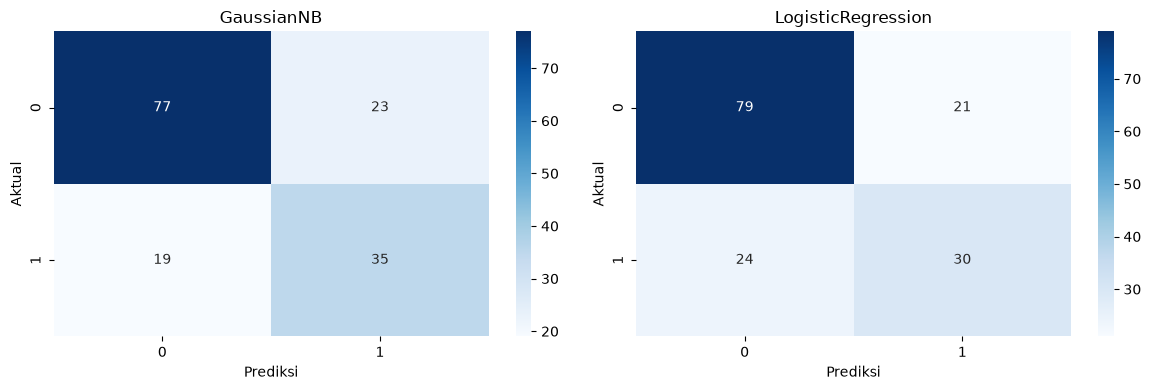

In [16]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, y_pred) in zip(axes, [('GaussianNB', y_pred_gnb), ('LogisticRegression', y_pred_lr)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

GaussianNB AUC: 0.8017
LogisticRegression AUC: 0.8263


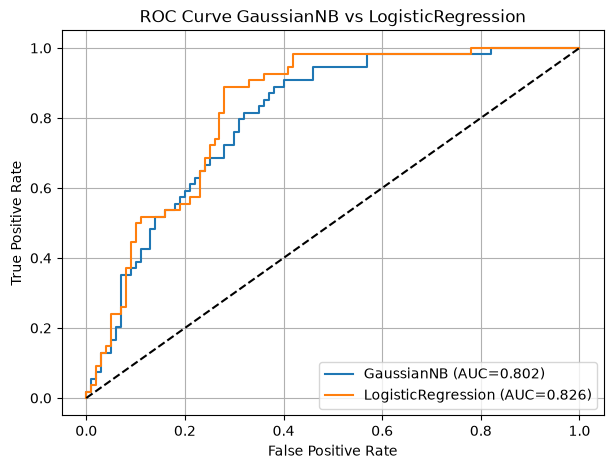

In [17]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(7, 5))
for name, y_prob in [('GaussianNB', y_prob_gnb), ('LogisticRegression', y_prob_lr)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    print(f'{name} AUC: {auc(fpr, tpr):.4f}')
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve GaussianNB vs LogisticRegression')
plt.legend()
plt.grid(True)
plt.show()

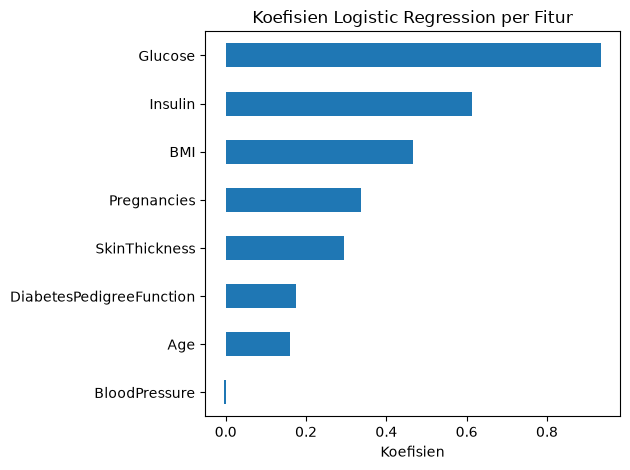

In [18]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
coef.plot(kind='barh', title='Koefisien Logistic Regression per Fitur')
plt.xlabel('Koefisien')
plt.tight_layout()
plt.show()

# 5. Analisis

### Hasil eksperimen (test set, n=154)

| Model | Akurasi | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| GaussianNB | 0,727 | 0,603 | 0,648 | 0,625 | 0,802 |
| LogisticRegression | 0,708 | 0,588 | 0,556 | 0,571 | 0,826 |

### 1. GaussianNB menang di threshold default, Logistic Regression menang di ranking

Hasilnya terlihat bertolak belakang: GaussianNB unggul di akurasi, precision, recall, dan F1, tetapi Logistic Regression unggul di AUC (0,826 vs 0,802). Ini dapat dijelaskan dari arti metriknya: F1 dihitung pada satu threshold tetap 0,5, sedangkan AUC mengukur kualitas urutan probabilitas di semua threshold. Artinya Logistic Regression sebenarnya lebih baik dalam mengurutkan pasien dari yang paling berisiko hingga paling aman, tetapi threshold 0,5 bukan titik keputusan terbaiknya pada data ini. Confusion matrix mengonfirmasi hal ini: GaussianNB benar mengenali 35 dari 54 pasien diabetes, sedangkan Logistic Regression hanya 30 dari 54. Jika threshold Logistic Regression digeser sedikit lebih rendah, F1-nya berpotensi menyusul atau melampaui GaussianNB.

### 2. Kaitan dengan asumsi dan representasi data

GaussianNB mengasumsikan tiap fitur berdistribusi normal di dalam tiap kelas dan saling bebas. Asumsi ini jelas disederhanakan (misalnya Insulin sangat miring/skew 3,03 dan fitur-fitur saling berkorelasi), tetapi pada data kecil (768 baris, 8 fitur) model sederhana justru tidak overfitting sehingga tetap kompetitif. Logistic Regression memodelkan batas keputusan linear pada fitur yang sudah di-scale; scaling penting baginya agar koefisien antar fitur sebanding, sedangkan bagi GaussianNB scaling tidak mengubah apa-apa secara matematis. Koefisien Logistic Regression juga sejalan dengan EDA: Glucose memiliki koefisien terbesar (0,93) sekaligus korelasi tertinggi dengan Outcome (0,50), disusul Insulin (0,61) dan BMI (0,47), sedangkan BloodPressure mendekati nol (-0,00) sesuai korelasinya yang lemah.

### 3. Catatan data: imbalance dan kebersihan

Dataset ini imbalance (500 negatif vs 268 positif, sekitar 65:35), sehingga akurasi 0,72 harus dibaca bersama recall: kedua model masih melewatkan sepertiga hingga hampir setengah pasien diabetes (recall 0,65 dan 0,56), yang secara medis adalah kesalahan paling berbahaya. Kabar baiknya, pengecekan menunjukkan dataset ini sudah bersih: tidak ada nilai 0 yang mustahil pada Glucose, BloodPressure, SkinThickness, Insulin, dan BMI, serta tidak ada missing value, sehingga imputasi median hanya menjadi pengaman tanpa mengubah data dan tidak ada isu leakage.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Pada threshold default 0,5, GaussianNB sedikit lebih baik (F1 0,625 vs 0,571) terutama karena recall lebih tinggi (0,648 vs 0,556): ia melewatkan lebih sedikit pasien diabetes.
2. Logistic Regression memiliki AUC lebih tinggi (0,826 vs 0,802), artinya potensi modelnya lebih baik jika threshold keputusannya dioptimasi, dan koefisiennya memberi interpretasi medis yang jelas dengan Glucose sebagai prediktor terkuat.
3. Kedua model masih jauh dari ideal untuk pemakaian klinis karena recall di bawah 0,65.

### Saran

1. Lakukan tuning threshold probabilitas (misalnya memakai kurva precision-recall) dan tangani imbalance dengan class weighting atau resampling agar recall kelas diabetes naik.
2. Gunakan cross-validation agar perbandingan tidak bergantung pada satu kali split 80:20.
3. Coba model non-linear seperti random forest atau gradient boosting yang dapat menangkap interaksi antar fitur (misalnya Glucose dengan BMI dan Age).